# Exploración + Outliers

El objetivo de esta fase es comprender la estructura del dataset, evaluar la calidad de los datos, identificar patrones de comportamiento y detectar posibles anomalías u outliers que puedan impactar el desempeño del modelo de churn.

In [ ]:
#Descarga de librerias necesarias

import pandas as pd
import numpy as np

In [ ]:
#Leer el archivo y visualizarlo

df = pd.read_csv("Dataset_Pruebas.csv")

df.head()

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
0,1,40,MX,46,3,24.461384,0
1,2,33,CL,57,4,39.683693,0
2,3,42,MX,52,6,75.392918,0
3,4,53,CL,41,7,181.208986,0
4,5,32,CL,45,4,31.608351,0


In [ ]:
#Revisar la informacion de los datos y describirlos

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               2020 non-null   int64  
 1   age                   2020 non-null   int64  
 2   country               2020 non-null   object 
 3   events_last_30d       2020 non-null   int64  
 4   purchases_last_30d    2020 non-null   int64  
 5   total_spend_last_30d  2020 non-null   float64
 6   churned               2020 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 110.6+ KB


,user_id,age,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
count,2020.000000,2020.000000,2020.000000,2020.000000,2020.000000,2020.000000
mean,1001.198020,35.143564,604.289109,5.151485,102.417796,0.095545
std,577.716056,12.711925,20259.186008,3.209357,72.059028,0.294038
min,1.000000,-5.000000,31.000000,0.000000,-300.000000,0.000000
25%,502.750000,27.000000,45.000000,3.000000,49.675697,0.000000
50%,1001.500000,35.000000,50.000000,5.000000,86.352292,0.000000
75%,1501.250000,43.000000,54.000000,7.000000,138.248008,0.000000
max,2000.000000,200.000000,900000.000000,50.000000,546.546479,1.000000


El dataset contiene 2,020 registros y 7 variables que representan el comportamiento de usuarios en una ventana móvil de los últimos 30 días. 

Distribución del target: 1,827 no churn (90.5%) vs 193 churn (9.5%) lo que nos muestra un dataset desbalanceado, lo cual es típico en problemas de churn. 

Análisis de distribuciones

* Edad: Concentrada entre 27–43 años y con una media de 35 años aqui, se identificaron valores imposibles en la variable age, incluyendo edades negativas y edades extremadamente altas (200 años), lo cual indica problemas de validación o captura de datos.

* events_last_30d: Esta variable presenta una distribución altamente sesgada debido a outliers extremos, aunque la mediana es cercana a 50 eventos, existen registros con valores de hasta 900.000 eventos, lo cual distorsiona significativamente la media y sugiere posibles problemas de calidad, automatización o actividad no humana.

* purchases_last_30d: En este caso la distribución es razonablemente simétrica, mediana 5, máximo 50.

* total_spend_last_30d: En este caso la mediana es de $86, pero hay valores negativos $-300 y un máximo de $546, puede que los valores negativos en total_spend_last_30d representen devoluciones o reversos transaccionales así que antes de eliminarlos, sería necesario validar con el área de negocio si forman parte de la lógica operativa esperada.

In [6]:
df["churned"].value_counts(normalize=True)

churned
0    0.904455
1    0.095545
Name: proportion, dtype: float64


* churned: La variable objetivo presenta desbalance de clases, con aproximadamente 9.5% de usuarios churners. Debido a esto, métricas como accuracy pueden resultar engañosas, por lo que se priorizarán métricas como F1-score y ROC-AUC.

In [4]:
df.isnull().sum()

user_id                 0
age                     0
country                 0
events_last_30d         0
purchases_last_30d      0
total_spend_last_30d    0
churned                 0
dtype: int64

In [5]:
df.duplicated().sum()

19

No se identificaron valores nulos en las variables analizadas, lo cual reduce la necesidad de imputación y simplifica el preprocesamiento inicial.

Se detectaron 19 registros duplicados, los cuales podrían generar sobre representación de ciertos usuarios y sesgar el entrenamiento del modelo. Pero debido a la naturaleza de ventana móvil, algunos registros similares podrían representar snapshots consecutivos del mismo usuario y no necesariamente duplicados erróneos por lo  que sería importante validar si existen timestamps asociados antes de eliminarlos automáticamente

### Revision Outliers

Matplotlib is building the font cache; this may take a moment.


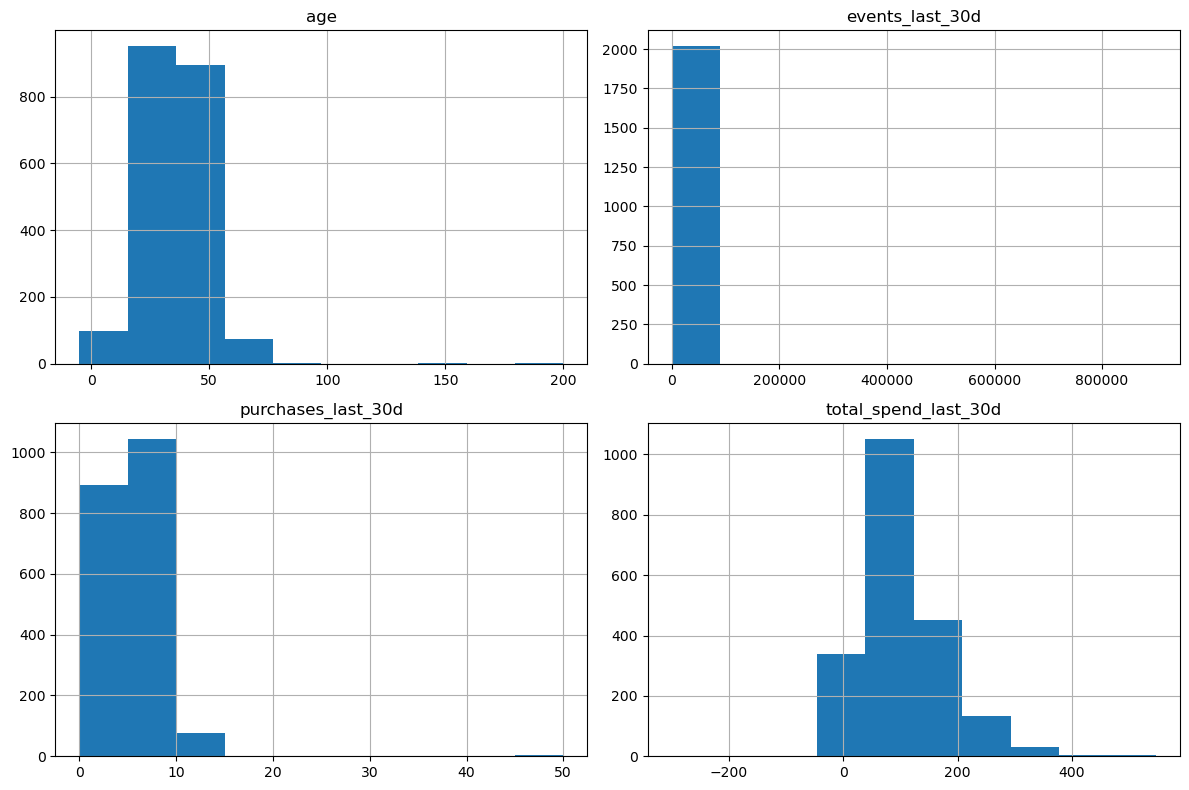

In [7]:
import matplotlib.pyplot as plt

numeric_cols = [
    "age",
    "events_last_30d",
    "purchases_last_30d",
    "total_spend_last_30d"
]

df[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

#### Tipos de Outliers Identificados y sus Validaciones

1. Outliers de dominio (imposibles físicamente)

Durante el análisis exploratorio se identificaron 4 registros con valores inválidos en la variable age:

age = -5 y age = -3 (2 registros); age = 150 y age = 200 (2 registros)

Estos valores representan edades físicamente imposibles y sugieren problemas de calidad de datos asociados a errores de captura, validación o procesos ETL. Aunque el volumen de registros afectados es bajo (4 de 2020 registros, equivalente a 0.2% del dataset), su presencia puede distorsionar estadísticas descriptivas y afectar negativamente modelos predictivos que utilicen la edad como variable explicativa.

Acción propuesta: Se recomienda eliminar estos registros antes del entrenamiento del modelo. Son errores de ingesta o captura y una edad negativa o de 200 años no tiene interpretación de negocio válida.

Justificación:  No existe una forma confiable de imputar una edad correcta a partir de estos valores, y mantenerlos introduciría ruido innecesario en el proceso de modelado. Adicionalmente, este tipo de anomalías no aporta señal de negocio relevante para la predicción de churn.

In [ ]:
# Mostrar registros atípicos
df[(df["age"] < 0) | (df["age"] > 100)]

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
77,78,-5,AR,42,10,81.685247,0
262,263,-3,MX,67,8,339.699547,0
457,458,150,CL,59,6,38.338142,0
585,586,200,AR,68,3,101.538103,0


In [ ]:
#Contarlos
invalid_age = df[(df["age"] < 0) | (df["age"] > 100)]
print(f"Cantidad de registros inválidos: {len(invalid_age)}")

Cantidad de registros inválidos: 4


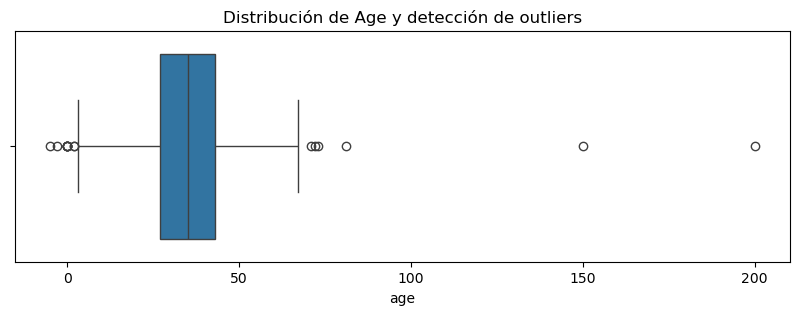

In [ ]:
#Graficarlos

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
sns.boxplot(x=df["age"])

plt.title("Distribución de Age y detección de outliers")
plt.show()

##### 2. Outliers estadísticos extremos (posibles bots o errores de sistema)

Durante el análisis exploratorio se identificaron registros con valores extremadamente altos en la variable events_last_30d. En particular, se detectaron 4 usuarios con 50.000, 120.000 y 900.000 eventos registrados dentro de una ventana móvil de 30 días. Adicionalmente, se identificó un registro duplicado asociado al usuario 866, lo cual refuerza la hipótesis de posibles problemas de calidad o duplicación de eventos.

La distribución presenta una asimetría extrema: aunque el 99% de los usuarios registra menos de 68 eventos, existen registros con cientos de miles de eventos, lo que incrementa artificialmente la media hasta 604 eventos.

Estos registros probablemente no corresponden a comportamiento humano normal y podrían estar relacionados con bots o tráfico automatizado, scraping, pruebas internas, errores de logging, duplicación de eventos o fallas en pipelines de tracking. Sin embargo, no se recomienda eliminarlos automáticamente, ya que podrían contener información relevante para detectar churn, fraude o comportamientos anómalos.

Acción propuesta: Se propone una estrategia híbrida:

1. Crear una variable bandera (is_bot_suspect): Identificar usuarios con actividad extremadamente alta para conservar la señal de anomalía dentro del modelo.

2. Aplicar capping (winsorización): Limitar los valores extremos al percentil 99 (~68 eventos) para evitar que unos pocos registros dominen la escala de la variable.

Justificación: Mantener valores como 900.000 eventos podría generar: distorsión estadística, sobreajuste del modelo, sensibilidad excesiva a anomalías e inestabilidad en escenarios de scoring diario. El capping permite preservar la información de “actividad inusualmente alta” sin afectar negativamente la distribución general de la variable y adicionalmente, en un contexto de rolling window, este tipo de outliers podría impactar diariamente el score predictivo y generar drift operacional si no se controla adecuadamente.

In [39]:
# Detectar y mostrar los registros
extreme_events = df[df["events_last_30d"] > 1000]
extreme_events

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
865,866,30,CL,50000,3,215.927995,0
1429,1430,31,CO,900000,3,77.195419,0
1458,1459,50,CL,120000,3,136.767290,0
2016,866,30,CL,50000,3,215.927995,0


In [40]:
#Contarlos
print(f"Cantidad de registros extremos: {len(extreme_events)}")

Cantidad de registros extremos: 4


In [41]:
#Validar percentiles
df["events_last_30d"].describe(percentiles=[0.90, 0.95, 0.99])

count      2020.000000
mean        604.289109
std       20259.186008
min          31.000000
50%          50.000000
90%          59.000000
95%          63.000000
99%          68.000000
max      900000.000000
Name: events_last_30d, dtype: float64

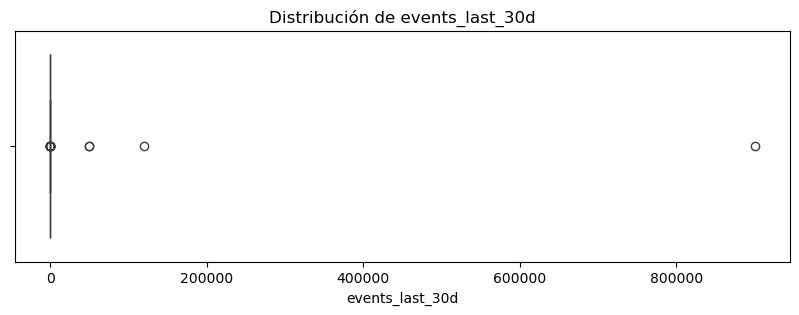

In [42]:
#Graficarlos

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

sns.boxplot(x=df["events_last_30d"])

plt.title("Distribución de events_last_30d")
plt.show()

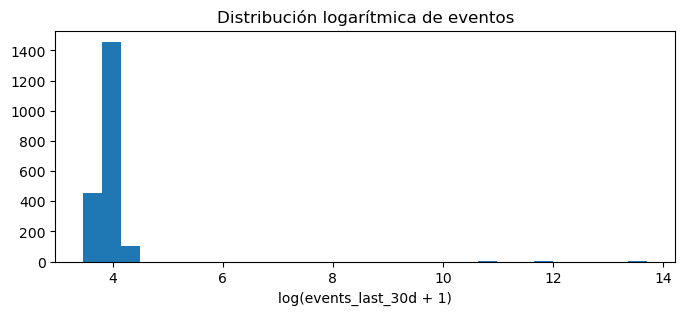

In [43]:
plt.figure(figsize=(8,3))

plt.hist(np.log1p(df["events_last_30d"]), bins=30)

plt.title("Distribución logarítmica de eventos")
plt.xlabel("log(events_last_30d + 1)")
plt.show()

##### 3. Outliers económicos (valores negativos)

Durante el análisis exploratorio se identificaron 3 registros con valores negativos en la variable total_spend_last_30d y a diferencia de otros outliers claramente inválidos, los valores negativos en variables monetarias pueden tener una interpretación legítima dentro del negocio y no necesariamente representan errores de calidad de datos. Ya que estos registros podrían estar asociados a devoluciones,reembolsos, chargebacks, cancelaciones de compra, ajustes financieros o compensaciones comerciales. Adicionalmente, este comportamiento puede ser una señal relevante de insatisfacción del usuario y potencial riesgo de churn.

Acción propuesta: No se recomienda eliminar automáticamente estos registros, en su lugar, se propone:

1. Crear una variable derivada (had_refund): Identificar usuarios que presentaron gasto negativo dentro de la ventana móvil.

2. Ajustar el valor monetario: Si se confirma que corresponden a devoluciones válidas, transformar el valor negativo a 0 para evitar distorsiones en métricas agregadas de gasto.

3. Validar con negocio: Confirmar con las áreas financieras o de producto si estos eventos forman parte del comportamiento esperado de la plataforma.

Justificación: Eliminar estos registros podría implicar pérdida de información predictiva relevante, ya que usuarios con devoluciones o experiencias negativas podrían presentar mayor probabilidad de abandono Por esta razón, resulta más apropiado preservar la señal comportamental mediante variables derivadas antes que excluir completamente los registros del análisis.

In [52]:
#Detectar registros negativos
negative_spend = df[df["total_spend_last_30d"] < 0]

negative_spend

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
44,45,17,MX,50,7,-300.0,0
1037,1038,17,MX,51,4,-50.0,0
1415,1416,46,AR,45,3,-100.0,0


In [ ]:
#contarlos
print(f"Cantidad de registros con gasto negativo: {len(negative_spend)}")

Cantidad de registros con gasto negativo: 3


In [54]:
df["total_spend_last_30d"].describe()

count    2020.000000
mean      102.417796
std        72.059028
min      -300.000000
25%        49.675697
50%        86.352292
75%       138.248008
max       546.546479
Name: total_spend_last_30d, dtype: float64

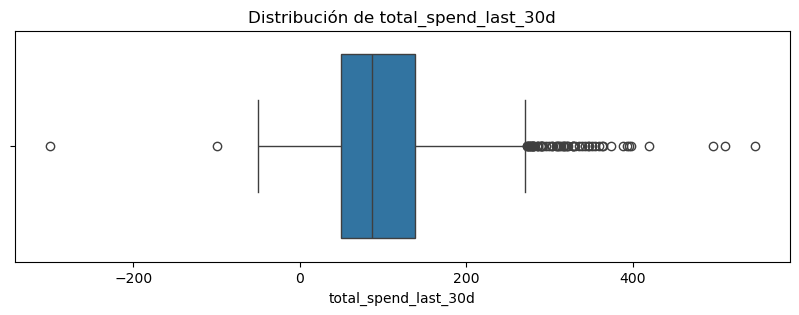

In [56]:
#Graficar

plt.figure(figsize=(10,3))

sns.boxplot(x=df["total_spend_last_30d"])

plt.title("Distribución de total_spend_last_30d")
plt.show()

### Otras variables revisadas

1. Con los siguientes datos encontramos que el dataset está muy balanceado por país y la variable country presenta una distribución relativamente balanceada entre los cuatro países analizados (CL, CO, MX y AR), con aproximadamente 500 registros por categoría.  Esta distribución homogénea reduce el riesgo de sesgo geográfico en el entrenamiento del modelo y permite realizar comparaciones más consistentes entre regiones.

2. El churn es muy parecido entre países y esto es importante porque indica: country probablemente NO es predictor fuerte y churn parece más relacionado con comportamiento individual que con región.

La tasa de churn se mantiene relativamente estable entre países, con valores cercanos al 9–10% en todas las regiones analizadas. Esto sugiere que el abandono de usuarios no parece estar fuertemente influenciado por factores geográficos, sino posiblemente por variables de comportamiento y actividad reciente. Adicionalmente, no se observan diferencias suficientemente grandes como para indicar sesgos regionales importantes dentro del dataset.

3. Correlaciones:  El análisis de correlación lineal muestra relaciones débiles entre las variables numéricas y la variable objetivo (churned). Esto puede indicar: relaciones no lineales,
interacción entre variables o que el churn depende de patrones más complejos que no se capturan mediante correlación simple.

Por esta razón, modelos no lineales como Random Forest podrían capturar mejor la dinámica del problema frente a modelos puramente lineales.

4. Análisis de usuarios extremos: El análisis de los registros con mayor cantidad de eventos refuerza la hipótesis de actividad anómala o problemas de tracking. Por ejemplo, algunos usuarios presentan cientos de miles de eventos dentro de una ventana de 30 días, mientras mantienen niveles normales de compras y gasto. Este comportamiento resulta inconsistente con patrones típicos de interacción humana y podría estar asociado a:

bots,
automatización,
duplicación de eventos,
pruebas internas,
o errores de logging.

Adicionalmente, se identificó un registro duplicado exacto para el usuario 866, lo cual incrementa la probabilidad de inconsistencias en procesos de ingesta o tracking.

In [47]:
df["country"].value_counts()

country
CL    512
CO    512
MX    498
AR    498
Name: count, dtype: int64

In [48]:
df.groupby("country")["churned"].mean()

country
AR    0.098394
CL    0.095703
CO    0.095703
MX    0.092369
Name: churned, dtype: float64

In [49]:
df.corr(numeric_only=True)

,user_id,age,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
user_id,1.000000,0.012179,0.018086,0.069889,-0.014704,0.054054
age,0.012179,1.000000,-0.004715,0.019948,0.014103,0.006134
events_last_30d,0.018086,-0.004715,1.000000,-0.018358,-0.002451,-0.008881
purchases_last_30d,0.069889,0.019948,-0.018358,1.000000,0.001603,0.010373
total_spend_last_30d,-0.014704,0.014103,-0.002451,0.001603,1.000000,0.032725
churned,0.054054,0.006134,-0.008881,0.010373,0.032725,1.000000


In [50]:
df.sort_values("events_last_30d", ascending=False).head(10)

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
1429,1430,31,CO,900000,3,77.195419,0
1458,1459,50,CL,120000,3,136.767290,0
2016,866,30,CL,50000,3,215.927995,0
865,866,30,CL,50000,3,215.927995,0
853,854,49,CO,75,5,111.928853,0
173,174,39,CL,74,8,120.562251,0
323,324,60,CO,72,6,46.043940,0
237,238,37,AR,70,3,279.294112,0
1236,1237,55,AR,70,3,76.494717,0
574,575,44,CL,70,3,49.248712,0


In [51]:
df.sort_values("total_spend_last_30d").head(10)

,user_id,age,country,events_last_30d,purchases_last_30d,total_spend_last_30d,churned
44,45,17,MX,50,7,-300.000000,0
1415,1416,46,AR,45,3,-100.000000,0
1037,1038,17,MX,51,4,-50.000000,0
907,908,43,AR,45,3,1.000000,0
337,338,31,CO,57,7,1.000000,0
1471,1472,27,CL,45,3,1.000000,0
817,818,45,CO,42,4,1.000000,0
1859,1860,38,AR,47,4,1.000000,1
1868,1869,21,MX,54,5,1.465442,0
1870,1871,21,AR,60,3,1.530380,0


### Rolling window

Las variables del dataset fueron calculadas utilizando una ventana móvil de 30 días (rolling window), lo que significa que los valores se actualizan diariamente según el comportamiento reciente del usuario, este enfoque permite construir modelos más dinámicos y cercanos al comportamiento real de los usuarios, facilitando escenarios de scoring casi en tiempo real. Sin embargo, también introduce desafíos importantes para el modelado y la operación del sistema.

1. Riesgo de data leakage temporal: Debido a que las variables se recalculan continuamente, existe riesgo de incluir información generada después del momento real de predicción del churn. Por ejemplo, si la ventana de eventos incluye actividad ocurrida posterior al evento de abandono, el modelo podría aprender patrones futuros que no estarían disponibles en producción.

2. Drift de variables (feature drift): En un esquema rolling window, las distribuciones de las variables pueden cambiar diariamente dependiendo del comportamiento de los usuarios por lo que el modelo puede perder capacidad predictiva con el tiempo si no se monitorean cambios en distribución y desempeño. Por ejemplo: cambios estacionales, campañas comerciales, promociones o eventos externos; pueden modificar rápidamente métricas como: cantidad de eventos, compras, o gasto reciente.

3. Alta correlación temporal entre observaciones: Las ventanas móviles generan solapamiento entre días consecutivos. Por ejemplo: la ventana del día 10 y del día 11 comparten 29 de los mismos 30 días, esto implica que observaciones cercanas en el tiempo no son completamente independientes. Si el split de entrenamiento y prueba no respeta el orden temporal, podría existir leakage indirecto entre conjuntos.

4. Inestabilidad del scoring: Pequeñas variaciones en actividad reciente pueden generar cambios frecuentes en el score del usuario. Por ejemplo: una compra, una devolución o algunos eventos adicionales pueden modificar significativamente las variables calculadas.El sistema puede generar scores altamente volátiles si no se implementan mecanismos de suavización o monitoreo.

### Riesgos de calidad de datos identificados

1. Errores de captura o validación: Se detectaron valores imposibles en variables de dominio como: edades negativas, edades extremadamente altas y actividad fuera de rangos humanos razonables; estos registros pueden distorsionar estadísticas descriptivas y afectar negativamente el aprendizaje del modelo.

2. Duplicación de registros o eventos: Se identificaron registros duplicados y posibles duplicaciones de actividad extrema, la duplicación puede inflar artificialmente métricas de comportamiento y generar sesgos en el entrenamiento.

3. Problemas de tracking o logging: La presencia de usuarios con cientos de miles de eventos dentro de 30 días sugiere posibles fallas de instrumentación, bots o errores de logging. El modelo podría aprender patrones artificiales que no representan comportamiento real de usuarios.

4. Inconsistencias financieras: Se identificaron valores negativos en variables monetarias. Sin contexto de negocio, estos valores podrían interpretarse erróneamente como errores cuando en realidad representan devoluciones o chargebacks legítimos.

5. Riesgo de drift operacional: Debido al uso de rolling windows, las distribuciones pueden cambiar rápidamente con el tiempo. Un modelo entrenado sobre una distribución histórica podría degradarse si los patrones de comportamiento evolucionan.

6. Dependencia temporal no controlada: La ausencia de timestamps visibles limita la validación de:
secuencia temporal, independencia entre observaciones y correcta separación train/test.Incrementa la probabilidad de leakage temporal durante el modelado.